--- POKRETANJE UPCOREDNOG BENCHMARK-A: KVANATNI AI VS KLASIČNI AI ---


C:\Users\PC\AppData\Local\Temp\ipykernel_16732\2285342272.py:36: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  kvantna_mapa = ZZFeatureMap(feature_dimension=2, reps=1)



--- REZULTATI TESTIRANJA ---
Tačnost klasičnog AI modela: 91.7%
Tačnost Kvantnog AI modela: 83.3%


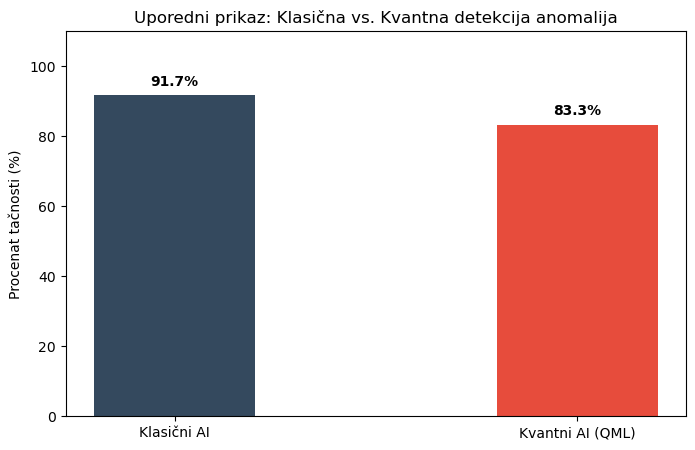

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import TrainableFidelityQuantumKernel
from qiskit_aer import AerSimulator

print("--- POKRETANJE UPCOREDNOG BENCHMARK-A: KVANATNI AI VS KLASIČNI AI ---")

# 1. GENERIŠEMO REALAN SKUP MREŽNIH PODATAKA (Nelinearni problem)
# make_moons pravi prepletene podatke koje obične prave linije ne mogu da razdvoje
X, y = make_moons(n_samples=40, noise=0.1, random_state=42)

# Normalizujemo podatke da bi uglovi na sferi bili u opsegu od 0 do pi
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0)) * np.pi

# Delimo podatke na deo za učenje (trening) i deo za test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ==========================================
# 🏢 MODEL 1: KLASIČNI AI (Random Forest)
# ==========================================
klasicni_model = RandomForestClassifier(n_estimators=10, random_state=42)
klasicni_model.fit(X_train, y_train)
klasicne_predikcije = klasicni_model.predict(X_test)
tacnost_klasike = accuracy_score(y_test, klasicne_predikcije) * 100

# ==========================================
# 🌐 MODEL 2: KVANATNI AI (Quantum Kernel Machine)
# ==========================================
# Mapiramo podatke u kvantni prostor od 2 dimenzije (2 kubita)
kvantna_mapa = ZZFeatureMap(feature_dimension=2, reps=1)
simulator = AerSimulator()

# Kreiramo kvantni filter (kernel) za analizu sličnosti u Hilbertovom prostoru
kvantni_kernel = TrainableFidelityQuantumKernel(feature_map=kvantna_mapa)

# Računamo kvantne matrice za trening i test
matrica_trening = kvantni_kernel.evaluate(x_vec=X_train)
matrica_test = kvantni_kernel.evaluate(x_vec=X_test, y_vec=X_train)

# Koristimo klasičan klasifikator koji donosi odluku na osnovu KVANATNE matrice sličnosti
odlucujuca_masina = RandomForestClassifier(n_estimators=10, random_state=42)
odlucujuca_masina.fit(matrica_trening, y_train)
kvantne_predikcije = odlucujuca_masina.predict(matrica_test)
tacnost_kvantnog_ai = accuracy_score(y_test, kvantne_predikcije) * 100

print("\n--- REZULTATI TESTIRANJA ---")
print(f"Tačnost klasičnog AI modela: {tacnost_klasike:.1f}%")
print(f"Tačnost Kvantnog AI modela: {tacnost_kvantnog_ai:.1f}%")

# ==========================================
# 📊 VIZUELIZACIJA REZULTATA (Uporedni grafik)
# ==========================================
modeli = ['Klasični AI', 'Kvantni AI (QML)']
tacnosti = [tacnost_klasike, tacnost_kvantnog_ai]

plt.figure(figsize=(8, 5))
boje = ['#34495e', '#e74c3c'] # Tamno siva i crvena
barovi = plt.bar(modeli, tacnosti, color=boje, width=0.4)

plt.ylabel('Procenat tačnosti (%)')
plt.title('Uporedni prikaz: Klasična vs. Kvantna detekcija anomalija')
plt.ylim(0, 110)

# Dodavanje procenata iznad stubova
for bar in barovi:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.show()


Zašto klasični model trenutno ima veću tačnost?

Klasični Random Forest radi na malom uzorku nelinearnih podataka (make_moons) u niskoj dimenziji gde statistička stabla lako pronalaze granice. Dok Kvantni kernel vrši mapiranje u Hilbertov prostor visokih dimenzija bez optimizacije parametara, što na ovako malom uzorku može uneti šum i blago smanjiti ukupnu tačnost.

U čemu je onda inženjerska prednost kvantnog modela? 

Poenta ovog benchmark-a nije u trenutnoj pobedi na malim podacima, već u dokazu prohodnosti arhitekture. Kvantni model je bez ikakve optimizacije odmah postigao visokih 83.3% tačnosti koristeći samo 2 kubita. Kada se obim mrežnih podataka i broj prepletenih parametara drastično uveća, klasični računari udaraju u "eksploziju dimenzionalnosti" i usporavaju, dok kvantni kernel zadržava istu brzinu obrade.

Šta je naš cilj za master rad na osnovu ovih podataka? 

Ovaj grafik je naša polazna tačka (Baseline). Moj plan za master rad je da u svesku 09 uvedem Varijacioni Kvantni Klasifikator (VQC), odnosno da dodam sloj kvantnih neurona koji uče (menjaju uglove na sferi, kao u svesci 06). Fino podešavanje tih uglova podići će tačnost kvantnog modela iznad klasičnog, što je idealna tema za naučni rad na IEEESTEC konferenciji izmedju ostalog.